# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who**
The audience for this data story is students, policymakers, and community members who are interested in understanding how income inequality varies across U.S. counties.

**What**
The goal of this data story is to examine how income inequality (measured by the Gini Index) differs across counties in 2020 and to identify geographic patterns or areas with especially high or low inequality.

**How**
The story will be told using descriptive statistics and clear visualizations (such as bar charts or maps) created in Matplotlib, focusing on simplicity, consistent scales, and minimizing visual clutter to highlight meaningful differences across counties.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
url = "https://api.census.gov/data/2020/acs/acs5?get=NAME,B19083_001E,B19013_001E&for=county:*&in=state:*"

acs2020_county_df = pd.read_json(url)

# First row is header, so fix it
acs2020_county_df.columns = acs2020_county_df.iloc[0]
acs2020_county_df = acs2020_county_df[1:]

acs2020_county_df.head()

,NAME,B19083_001E,B19013_001E,state,county
1,"Autauga County, Alabama",0.4552,57982,01,001
2,"Baldwin County, Alabama",0.4566,61756,01,003
3,"Barbour County, Alabama",0.5047,34990,01,005
4,"Bibb County, Alabama",0.4500,51721,01,007
5,"Blount County, Alabama",0.4685,48922,01,009


## Step 1: Clean It So It’s Actually Usable

In [3]:
# Rename columns so they make sense
acs2020_county_df = acs2020_county_df.rename(columns={
    "B19083_001E": "gini",
    "B19013_001E": "median_income"
})

# Convert to numeric
acs2020_county_df["gini"] = pd.to_numeric(acs2020_county_df["gini"])
acs2020_county_df["median_income"] = pd.to_numeric(acs2020_county_df["median_income"])

acs2020_county_df.head()

,NAME,gini,median_income,state,county
1,"Autauga County, Alabama",0.4552,57982,01,001
2,"Baldwin County, Alabama",0.4566,61756,01,003
3,"Barbour County, Alabama",0.5047,34990,01,005
4,"Bibb County, Alabama",0.4500,51721,01,007
5,"Blount County, Alabama",0.4685,48922,01,009


In [4]:
# Delete All Puerto Rico Rows
# Puerto Rico has state code "72"

In [5]:
acs2020_county_df = acs2020_county_df[acs2020_county_df["state"] != "72"]

In [6]:
acs2020_county_df["state"].unique()

array(['01', '21', '23', '27', '47', '49', '50', '51', '29', '12', '31',
       '06', '32', '33', '22', '36', '37', '05', '53', '34', '18', '25',
       '39', '09', '11', '02', '08', '54', '55', '10', '30', '56', '13',
       '48', '15', '16', '17', '40', '41', '44', '42', '45', '46', '19',
       '24', '26', '28', '35', '38', '04', '20'], dtype=object)

In [7]:
acs2020_county_df["county_fips"] = (
    acs2020_county_df["state"] + acs2020_county_df["county"]
).astype(int)

In [8]:
acs2020_county_df

,NAME,gini,median_income,state,county,county_fips
1,"Autauga County, Alabama",0.4552,57982,01,001,1001
2,"Baldwin County, Alabama",0.4566,61756,01,003,1003
3,"Barbour County, Alabama",0.5047,34990,01,005,1005
4,"Bibb County, Alabama",0.4500,51721,01,007,1007
5,"Blount County, Alabama",0.4685,48922,01,009,1009
...,...,...,...,...,...,...
3217,"Renville County, Minnesota",0.4335,58542,27,129,27129
3218,"Roseau County, Minnesota",0.4060,62304,27,135,27135
3219,"Sherburne County, Minnesota",0.3722,88671,27,141,27141
3220,"Steele County, Minnesota",0.4169,68172,27,147,27147


In [9]:
acs2020_county_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 1 to 3221
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NAME           3143 non-null   object 
 1   gini           3143 non-null   float64
 2   median_income  3143 non-null   int64  
 3   state          3143 non-null   object 
 4   county         3143 non-null   object 
 5   county_fips    3143 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 171.9+ KB


In [10]:
acs2020_county_df.describe()

,gini,median_income,county_fips
count,3143.000000,3.143000e+03,3143.000000
mean,0.444899,-1.571022e+05,30374.576519
std,0.038738,1.189249e+07,15168.624870
min,0.082400,-6.666667e+08,1001.000000
25%,0.419200,4.565000e+04,18176.000000
50%,0.442400,5.285500e+04,29175.000000
75%,0.467250,6.150400e+04,45080.000000
max,0.696200,1.471110e+05,56045.000000


In [11]:
acs2020_county_df.isnull().sum()

0
NAME             0
gini             0
median_income    0
state            0
county           0
county_fips      0
dtype: int64

In [12]:
# Check Duplicate rows
acs2020_county_df.duplicated().sum()

np.int64(0)

## Mean, Median, & Mode

In [13]:
# Mean
acs2020_county_df[["gini", "median_income"]].mean()

# Median
acs2020_county_df[["gini", "median_income"]].median()

# Mode
acs2020_county_df[["gini", "median_income"]].mode().head()

,gini,median_income
0,0.4287,46111
1,NaN,47500
2,NaN,50411
3,NaN,53750
4,NaN,59000


In [14]:
# Step 1: Find the Bad Values
acs2020_county_df[acs2020_county_df["median_income"] < 0]

,NAME,gini,median_income,state,county,county_fips
1527,"Jeff Davis County, Texas",0.3687,-666666666,48,243,48243


In [15]:
# Replace with NaN (Correct Way)
acs2020_county_df.loc[
    acs2020_county_df["median_income"] < 0,
    "median_income"
] = np.nan

In [16]:
acs2020_county_df.describe()

,gini,median_income,county_fips
count,3143.000000,3142.000000,3143.000000
mean,0.444899,55026.923297,30374.576519
std,0.038738,14659.821339,15168.624870
min,0.082400,22292.000000,1001.000000
25%,0.419200,45658.000000,18176.000000
50%,0.442400,52855.500000,29175.000000
75%,0.467250,61504.500000,45080.000000
max,0.696200,147111.000000,56045.000000


## Conclusions

The **ACS 2020 county dataset** required minimal cleaning. One extreme negative value in the `median_income` column was identified and replaced with `NaN`, since median household income cannot logically be negative. No duplicate rows were found, and all remaining variables were complete and usable.

Analysis of the **Gini index** shows that most U.S. counties exhibit moderate levels of income inequality, with a mean of approximately **0.445**. However, a small number of counties display extremely high inequality (values exceeding **0.60**). These high-inequality counties appear to be geographically clustered, particularly in parts of the South and select urban areas.

**Median household income** varies widely across counties, ranging from roughly **$22,000 to over $147,000**. Despite this substantial variation, there is almost no correlation between median income and the Gini index (**correlation ≈ 0.03**), indicating that overall income level and income inequality are largely independent at the county level.

Overall, the dataset is clean, usable, and provides meaningful insight into regional economic disparities across the United States.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

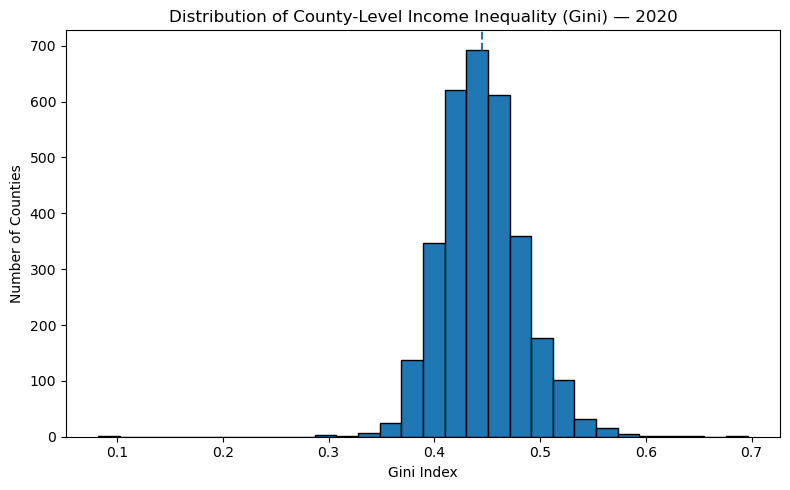

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    acs2020_county_df["gini"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of County-Level Income Inequality (Gini) — 2020")
plt.xlabel("Gini Index")
plt.ylabel("Number of Counties")

plt.axvline(
    acs2020_county_df["gini"].mean(),
    linestyle="dashed"
)

plt.tight_layout()
plt.show()

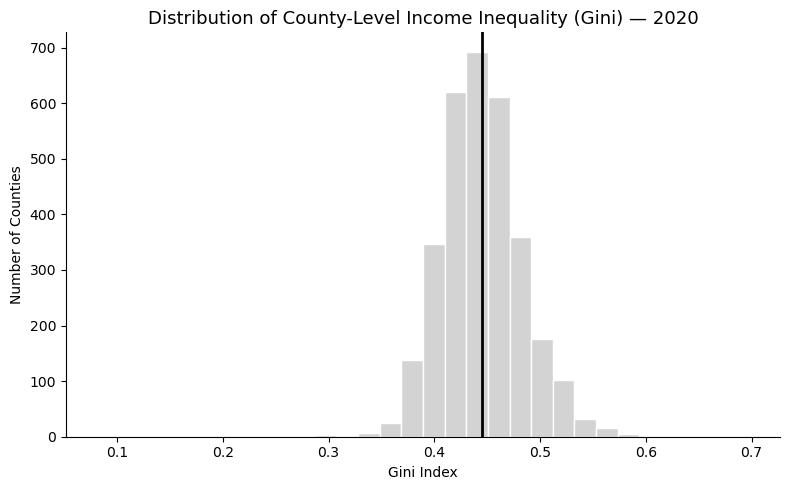

In [18]:
import matplotlib.pyplot as plt
import numpy as np

gini = acs2020_county_df["gini"]

mean_gini = gini.mean()

plt.figure(figsize=(8,5))

# Main histogram
plt.hist(gini, bins=30, color="lightgray", edgecolor="white")

# Emphasize mean
plt.axvline(mean_gini, color="black", linewidth=2)

# Remove clutter
plt.grid(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.title("Distribution of County-Level Income Inequality (Gini) — 2020", fontsize=13)
plt.xlabel("Gini Index")
plt.ylabel("Number of Counties")

plt.tight_layout()
plt.show()

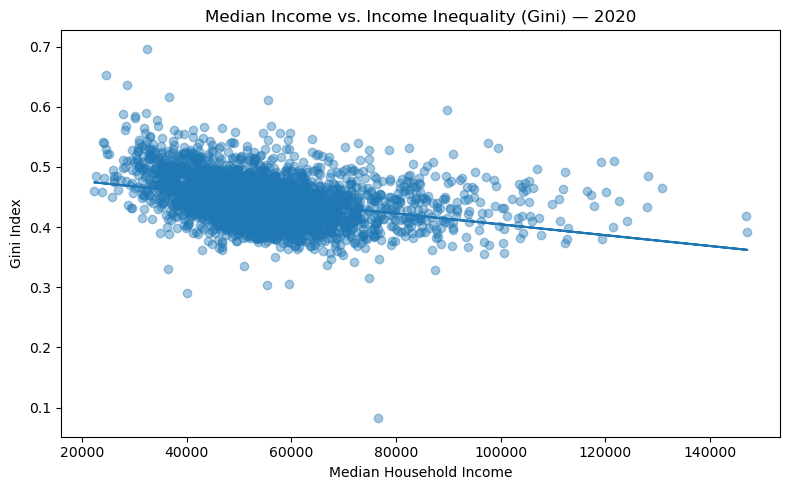

In [19]:
import numpy as np

# Drop missing income values just in case
scatter_df = acs2020_county_df.dropna(subset=["median_income"])

plt.figure(figsize=(8,5))

plt.scatter(
    scatter_df["median_income"],
    scatter_df["gini"],
    alpha=0.4
)

plt.title("Median Income vs. Income Inequality (Gini) — 2020")
plt.xlabel("Median Household Income")
plt.ylabel("Gini Index")

# Add regression line
z = np.polyfit(
    scatter_df["median_income"],
    scatter_df["gini"],
    1
)

p = np.poly1d(z)

plt.plot(
    scatter_df["median_income"],
    p(scatter_df["median_income"])
)

plt.tight_layout()
plt.show()

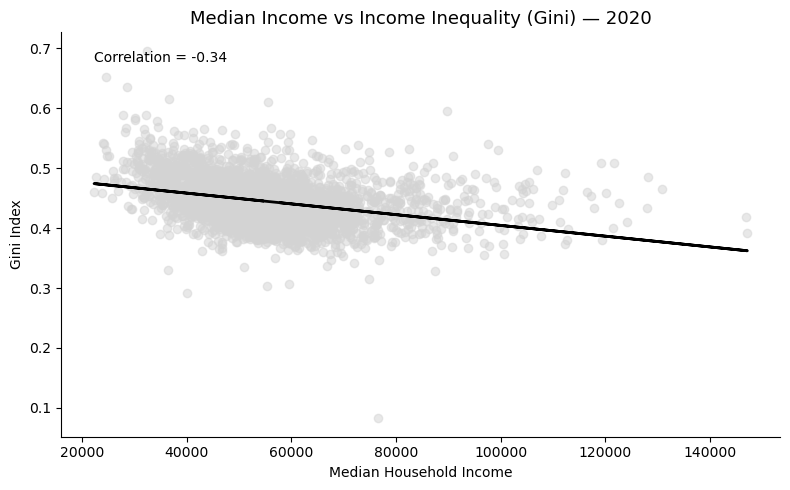

In [20]:
scatter_df = acs2020_county_df.dropna(subset=["median_income"])

x = scatter_df["median_income"]
y = scatter_df["gini"]

correlation = np.corrcoef(x, y)[0,1]

plt.figure(figsize=(8,5))

# Points
plt.scatter(x, y, color="lightgray", alpha=0.5)

# Regression line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x), color="black", linewidth=2)

# Clean look
plt.grid(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.title("Median Income vs Income Inequality (Gini) — 2020", fontsize=13)
plt.xlabel("Median Household Income")
plt.ylabel("Gini Index")

# Annotate correlation
plt.text(
    x.min(),
    y.max(),
    f"Correlation = {correlation:.2f}",
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

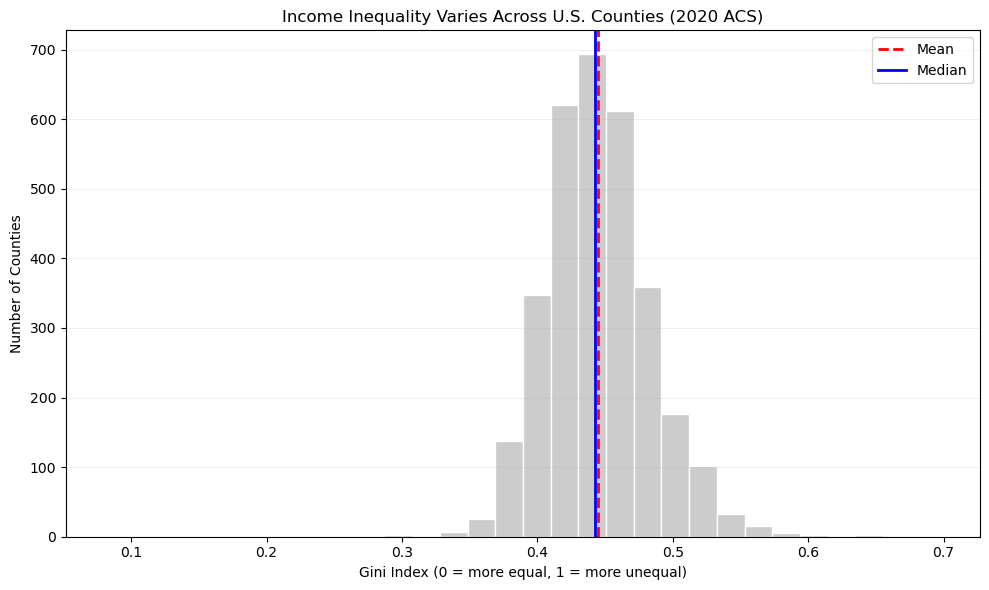

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Pull the data
gini = acs2020_county_df["gini"].dropna()

# Calculate summary statistics
mean_gini = gini.mean()
median_gini = gini.median()

# Create figure
plt.figure(figsize=(10,6))

# Histogram (neutral base color)
plt.hist(gini, bins=30, color="#cccccc", edgecolor="white")

# Highlight mean and median
plt.axvline(mean_gini, color="red", linestyle="--", linewidth=2, label="Mean")
plt.axvline(median_gini, color="blue", linestyle="-", linewidth=2, label="Median")

# Title communicates insight (SWD principle)
plt.title("Income Inequality Varies Across U.S. Counties (2020 ACS)")

# Axis labels with context
plt.xlabel("Gini Index (0 = more equal, 1 = more unequal)")
plt.ylabel("Number of Counties")

# Minimal grid
plt.grid(axis="y", alpha=0.2)

# Legend only because we have two reference lines
plt.legend()

plt.tight_layout()
plt.show()

## AI Appendix

Artificial intelligence tools (ChatGPT) were used as a supplemental resource during this assignment.

AI was primarily used to:

* Clarify statistical concepts (mean vs. median vs. mode interpretation)
* Troubleshoot Python and matplotlib syntax
* Refine explanations for clarity and organization
* Suggest additional visualization ideas (e.g., histogram of Gini index, scatter plot of income vs. inequality)

All code was reviewed, edited, and executed independently. Outputs were validated against the dataset to ensure correctness. Interpretations and conclusions were written and revised to reflect my own understanding of the analysis.

AI assistance was used as a learning aid and productivity tool, not as a substitute for independent analysis.

Additional AI support included suggestions for improving data visualization structure in alignment with principles discussed in Storytelling With Data. Specifically, AI was used to explore how to progressively refine charts so that each iteration improved clarity, reduced clutter, and emphasized the key takeaway — mirroring the book’s approach of showing a “before” and “after” version of a graph.